In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
print(df.isna().sum())
print("Shape:", df.shape) 
print("Duplicates:", df.duplicated().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Shape: (1025, 14)
Duplicates: 723


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print("New shape:", df.shape)

New shape: (302, 14)


In [10]:
print(df['target'].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
1    164
0    138
Name: count, dtype: int64
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [11]:
print(df.describe().T)

          count        mean        std    min     25%    50%     75%    max
age       302.0   54.420530   9.047970   29.0   48.00   55.5   61.00   77.0
sex       302.0    0.682119   0.466426    0.0    0.00    1.0    1.00    1.0
cp        302.0    0.963576   1.032044    0.0    0.00    1.0    2.00    3.0
trestbps  302.0  131.602649  17.563394   94.0  120.00  130.0  140.00  200.0
chol      302.0  246.500000  51.753489  126.0  211.00  240.5  274.75  564.0
fbs       302.0    0.149007   0.356686    0.0    0.00    0.0    0.00    1.0
restecg   302.0    0.526490   0.526027    0.0    0.00    1.0    1.00    2.0
thalach   302.0  149.569536  22.903527   71.0  133.25  152.5  166.00  202.0
exang     302.0    0.327815   0.470196    0.0    0.00    0.0    1.00    1.0
oldpeak   302.0    1.043046   1.161452    0.0    0.00    0.8    1.60    6.2
slope     302.0    1.397351   0.616274    0.0    1.00    1.0    2.00    2.0
ca        302.0    0.718543   1.006748    0.0    0.00    0.0    1.00    4.0
thal      30

Total 14 columns
├── target (target column)
├── Continuous numeric (5): age, trestbps, chol, thalach, oldpeak
│   └── Scaling (StandardScaler)
└── Categorical (8): sex, cp, fbs, restecg, exang, slope, ca, thal
    └── Encoding (One-Hot), not scaling

Original shape: (1025, 14), no missing values.
Found 723 duplicate rows → dropped duplicates → final shape: (302, 14).
Target balance: 54.3% disease (1), 45.7% no disease (0) → reasonably balanced, accuracy is a valid metric here (not misleading like a 95:5 split would be).
Feature types identified:
Continuous numeric (need scaling): age, trestbps, chol, thalach, oldpeak
Ordinal (numeric-like order, scale as numeric): ca
Nominal categorical (need One-Hot Encoding): sex, cp, fbs, restecg, exang, slope, thal

# Univariate Analysis

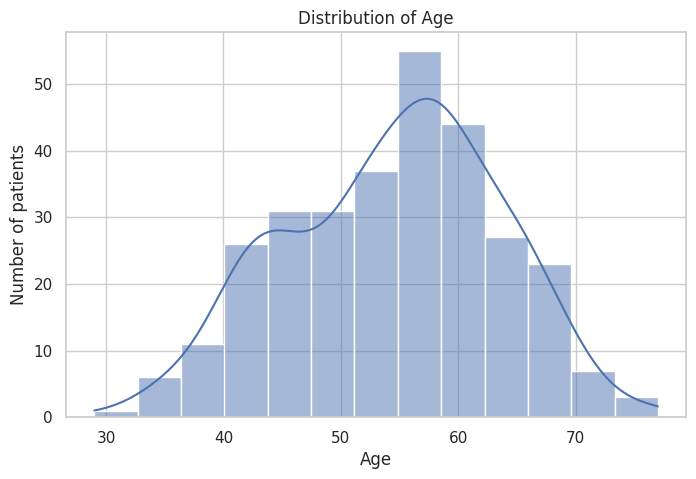

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel("Number of patients")
plt.show()

Age distribution (univariate):

* Roughly bell-shaped but left-skewed with a slight bimodal shape — one small bump around 44–48, one larger peak around 55–58.
* Peak patient age: ~55–58 years.
* Not a perfectly normal distribution, so StandardScaler will be a slight approximation but acceptable.

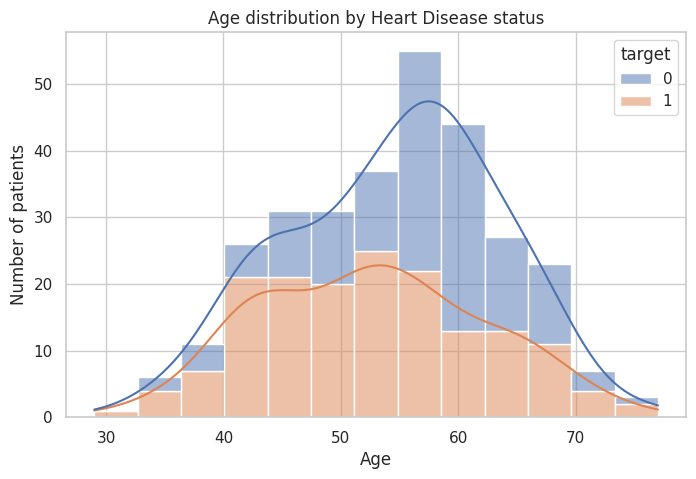

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', hue='target', kde=True, multiple='stack')
plt.title("Age distribution by Heart Disease status")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

Age vs Target (bivariate):

* Counter-intuitive pattern: younger patients (40–52) show a higher proportion of disease (target=1), while older patients (55–70) show a higher proportion of no-disease (target=0).
* Confirmed target=1 = disease present, target=0 = no disease (no label reversal).
* Likely explanation: selection bias — younger patients in this clinical dataset may have come in specifically due to symptoms, while older patients may include more routine-checkup (healthy) cases. Could also be partly small-sample noise (n=302).
* Conclusion: age alone is a weak/inconsistent predictor in this dataset.

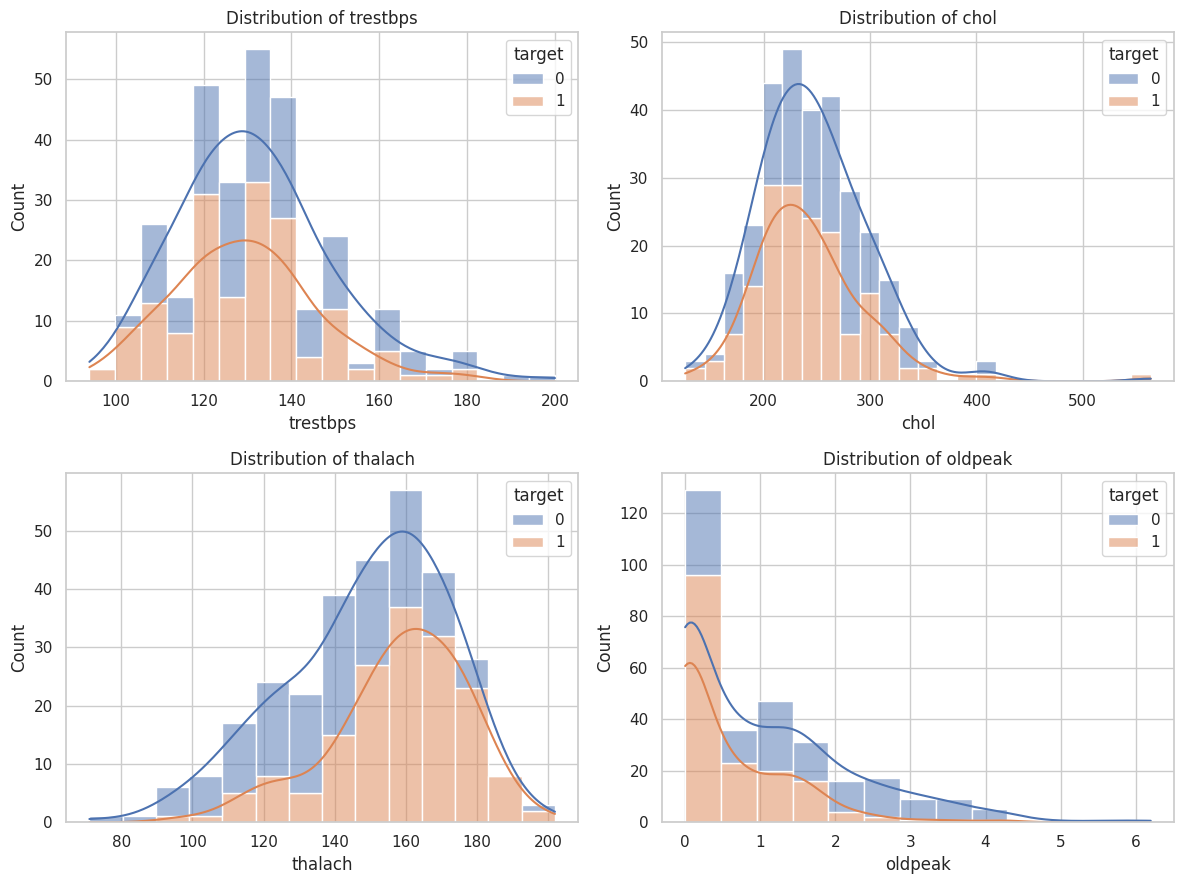

In [15]:
num_cols = ["trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
   sns.histplot(data=df, x=col, hue="target", kde=True, multiple="stack", ax=ax)
   ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

1. trestbps (resting blood pressure) vs Target:

* Large overlap between disease/no-disease distributions.
* Weak standalone predictor.

2. chol (cholesterol) vs Target:

* Distributions nearly identical in shape between the two classes.
* Weakest standalone predictor among the numeric features, despite cholesterol being a classically expected risk factor — may only add value in combination with other features.
* Contains a few visible outliers in the 400–560+ range.

3. thalach (max heart rate) vs Target:

* Clear separation: patients with disease (target=1) skew toward higher max heart rate (~150–180), while healthy patients cluster more in the 120–150 range.
* Strong standalone predictor.

4. oldpeak (ST depression) vs Target:

* Clear separation: oldpeak ≈ 0 is associated with more healthy patients; as oldpeak increases, proportion of disease patients increases.
* Strong standalone predictor, consistent with its clinical role as a stress-test marker.

5. Relative feature strength (visual, to be confirmed numerically via correlation):

chol < trestbps < age  <  thalach ≈ oldpeak
(weak)                    (strong)

6. Key conceptual takeaway — feature redundancy:

* Physiologically, age and thalach are expected to be negatively related (max heart rate declines with age, per the rough rule max HR ≈ 220 − age).
* If two features are correlated, they carry overlapping information — including both in a distance-based model like KNN can cause implicit "double-counting" of the same underlying signal.

7. Next step: quantify this relationship using a correlation heatmap (df.corr() + sns.heatmap) to numerically verify which features are redundant and which are most associated with target.

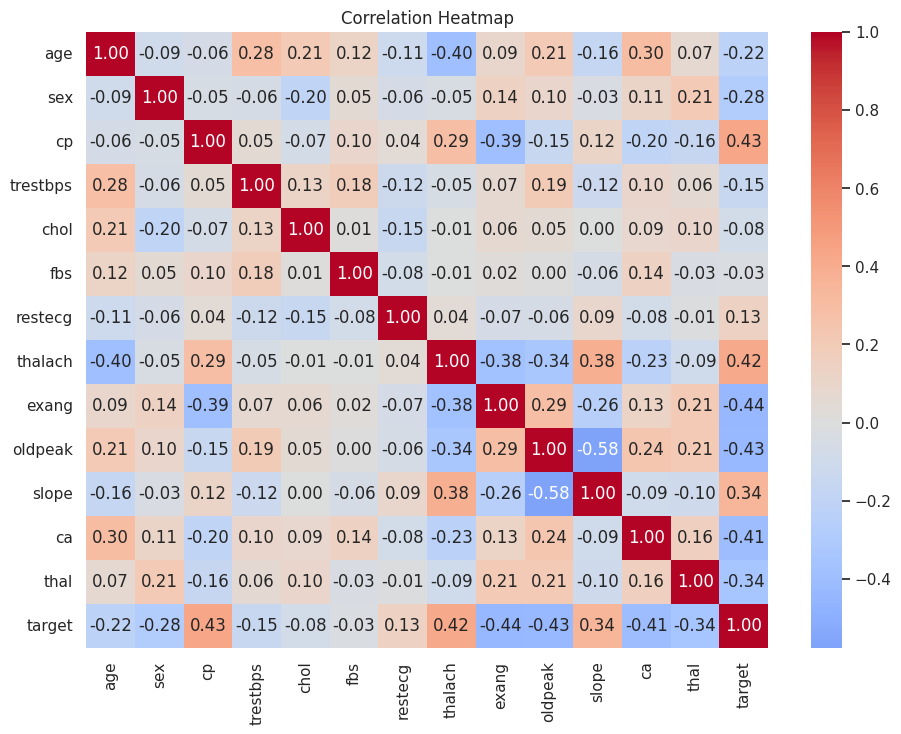

In [18]:
plt.figure(figsize=(11,8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

📓 Notes: Correlation Heatmap Analysis

1. Method: df.corr() computes Pearson correlation coefficient between every pair of numeric columns, values range from −1 to +1. Magnitude = strength of relationship, sign = direction (+ve = move together, −ve = move oppositely). Diagonal is always 1.00 (self-correlation) and carries no information.

2. Correlation with target (sorted by strength):

* Strong (|r| > 0.4):   cp (+0.43), exang (−0.44), thalach (+0.42),
                       oldpeak (−0.43), ca (−0.41)
* Medium (0.3–0.4):     slope (+0.34), thal (−0.34)
* Weak (0.1–0.3):       sex (−0.28), age (−0.22), restecg (+0.13),
                       trestbps (−0.15)
* Negligible (<0.1):    fbs (−0.03), chol (−0.08)

3. Key finding: chol, despite being a classically known risk factor, shows almost no linear correlation with target (−0.08) in this dataset, consistent with the weak signal seen in its univariate/bivariate distribution plot. Likely to contribute little standalone predictive value; may need interaction with other features or may simply be a weak feature in this particular sample.

4. Confirmed feature redundancy (multicollinearity candidates):

* age and thalach: r = −0.40 → moderately strong negative relationship, consistent with the known physiological pattern that max heart rate declines with age (approx. 220 − age).
* oldpeak and slope: r = −0.58 → the strongest off-diagonal correlation in the dataset; these two features are substantially redundant.

5. Implication for modeling:

* Redundant/correlated feature pairs contribute overlapping information to distance-based calculations in KNN, effectively over-weighting that shared signal.
* Candidates for chol and weak features: consider dropping or de-prioritizing via feature selection (SelectKBest/mutual information) in Stage 7.
* Candidates for age/thalach and oldpeak/slope: candidates for PCA-based dimensionality reduction, or careful feature selection to avoid double-counting correlated signal.
* Note: correlation only captures linear relationships — a feature with low linear correlation to target could still be informative in combination with others or via non-linear interactions; mutual information